In [22]:
import datajoint as dj
dj.config.load('C:\\Secrets\\dj_local_conf.json')
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
import numpy as np
# connect to the database

[2026-06-15 12:38:51,417][INFO]: DataJoint is configured from C:\Secrets\dj_local_conf.json


Text(0, 0.5, 'Number of Trials')

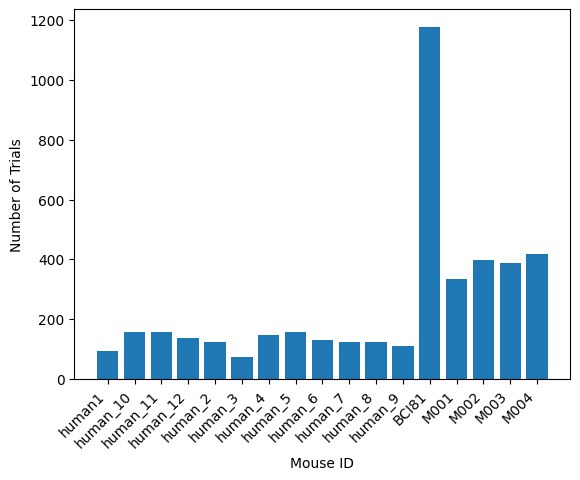

In [23]:
# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


In [24]:
# order the subject IDs based on the number at the end of the ID, and ignore those that do not have a number at the end of the ID
subject_ids_ordered = []
subject_id_indices = []
include_benjamin = False

for subject_id in mouse_IDs[needed_mice]:
    if 'human' not in subject_id:
        if 'bbenjamin' in subject_id and include_benjamin:
            subject_id_indices.append(-1)
            subject_ids_ordered.append(subject_id)
            continue
        else:
            continue
    if '_' not in subject_id:
        subject_id_indices.append(int(subject_id[-1]))
    else:
        try:
            subject_id_indices.append(int(subject_id.split('_')[-1]))
        except:
            subject_id_indices.append(None)
    subject_ids_ordered.append(subject_id)
subject_id_indices = np.array(subject_id_indices)
subject_ids_ordered = np.array(subject_ids_ordered)
needed = subject_id_indices !=None
subject_id_indices = subject_id_indices[needed]
subject_ids_ordered = subject_ids_ordered[needed]
subject_ids_ordered = subject_ids_ordered[np.argsort(subject_id_indices)]
subject_id_indices = subject_id_indices[np.argsort(subject_id_indices)]

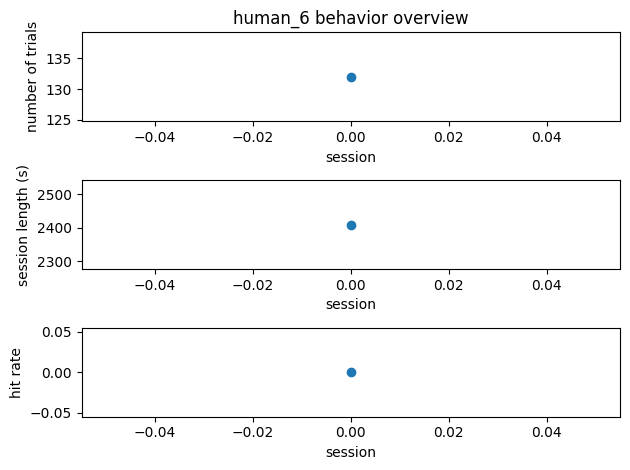

In [25]:

#subject_id = 'M004'#'mouse_bbenjamin'#'BCI81'
subject_id = 'mouse_judith'
#subject_id = 'mouse_bbenjamin'
subject_id = 'human_6'

available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
trial_nums = []
hit_rates = []
session_lengths = []
for session in available_sessions:
    trials = (experiment.SessionTrial()&{'subject_id':subject_id,
                                         'session':session}).fetch('trial')
    trial_nums.append(len(trials))
    hits = len(experiment.BehaviorTrial()&{'subject_id':subject_id,'session':session,'outcome':'hit'})
    hit_rate = hits/len(trials) if len(trials)>0 else np.nan
    hit_rates.append(hit_rate)
    session_length = (experiment.SessionTrial()&{'subject_id':subject_id,'session':session,'trial':np.max(trials)}).fetch1('trial_end_time')
    session_lengths.append(session_length)
fig = plt.figure()
ax1 = fig.add_subplot(3,1,1)
ax1.plot(available_sessions,trial_nums,'o-')
ax1.set_xlabel('session')
ax1.set_ylabel('number of trials')
plt.title(f'{subject_id} behavior overview')
ax2 = fig.add_subplot(3,1,2)
ax2.plot(available_sessions,session_lengths,'o-')
ax2.set_xlabel('session')
ax2.set_ylabel('session length (s)')
ax3 = fig.add_subplot(3,1,3)
ax3.plot(available_sessions,hit_rates,'o-')
ax3.set_xlabel('session')
ax3.set_ylabel('hit rate')
plt.tight_layout()
plt.show()

C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\4153730092.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\4153730092.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\4153730092.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\4153730092.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\4153730092.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\4153730092.py:78: RuntimeWarning: divide by zero encounte

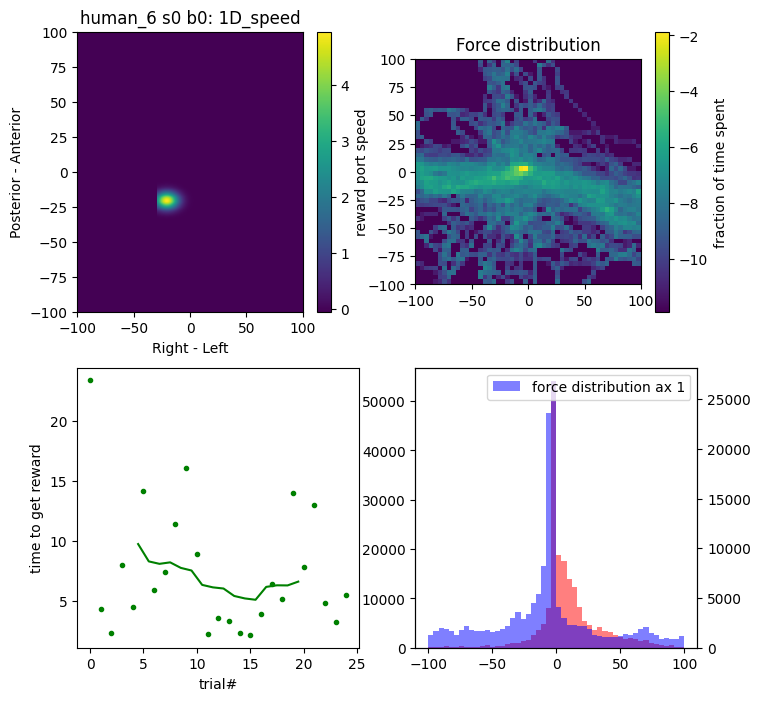

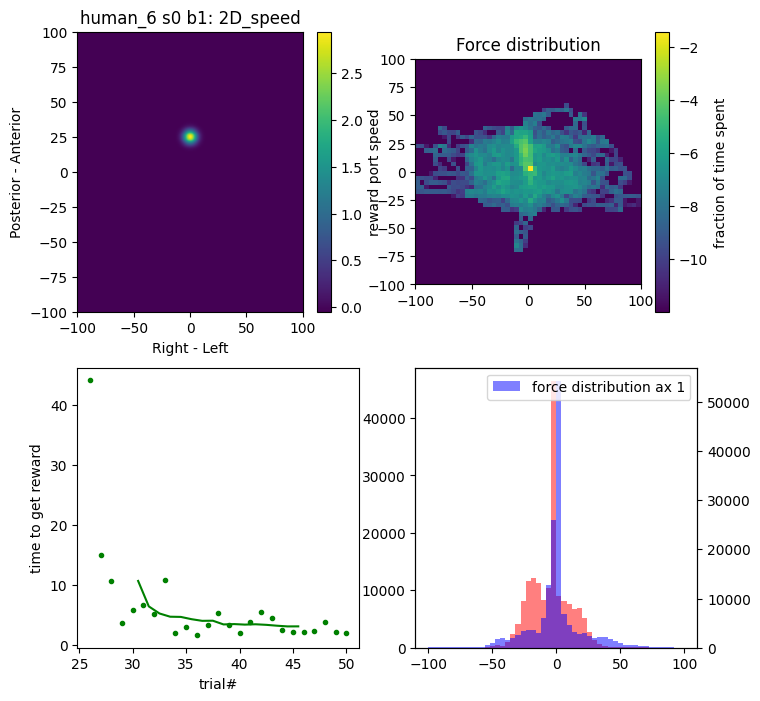

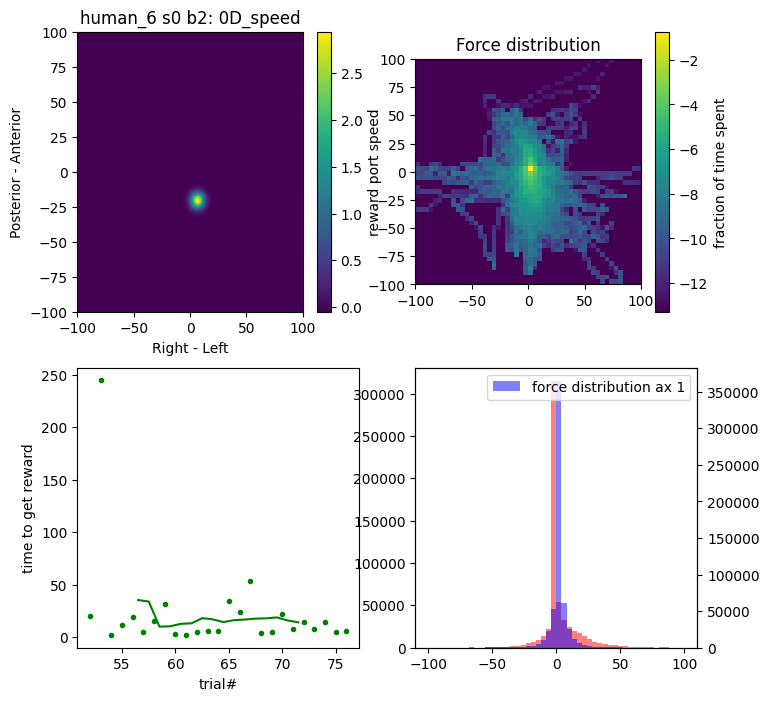

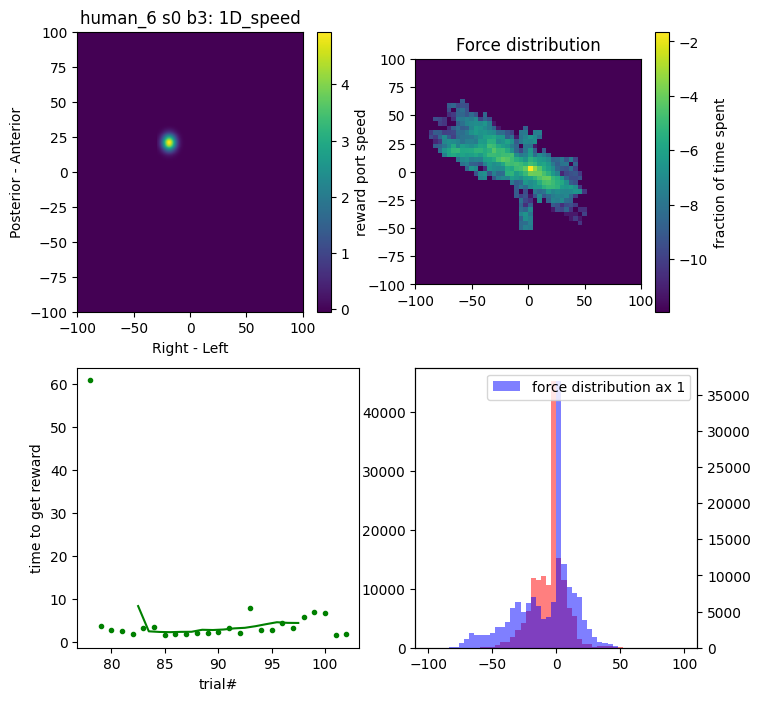

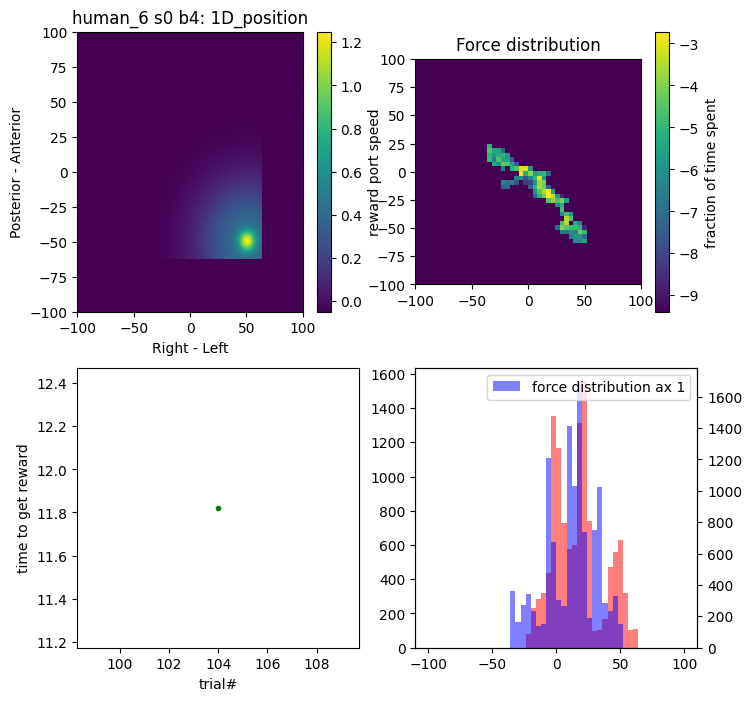

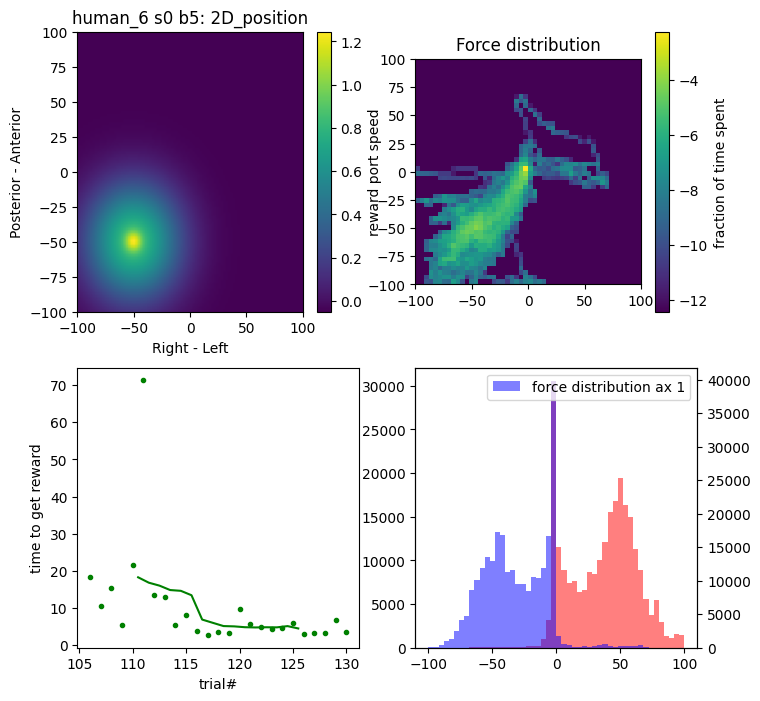

In [26]:
# visualize targets, and how forces change over sessions and trials
import matplotlib.pyplot as plt
subtract_force_median = False
force_uniform_range = True
uniform_force_range= np.asarray([-1,1,-1,1])*100

for session_i, session in enumerate(available_sessions):
    available_blocks,feedback_types = (experiment.Block()&{'subject_id':subject_id,'session':session}).fetch('block','feedback_type')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    
    for block,feedback_type in zip(available_blocks,feedback_types):
        task_setting_id,target_force_lut = (experiment.TaskSettings()*experiment.Block() &{'subject_id':subject_id,'session':session,'block':block}).fetch1('task_setting_id','target_force_lut')
        
        fig = plt.figure(figsize=(8,8))
        ax_target_LUT = fig.add_subplot(2,2,1)
        force_axes_dict = {}
        for fa in force_axes:
            if fa['task_setting_id'] == task_setting_id:
                force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                    'target_force_axes':fa['target_force_axes']}
        if force_uniform_range:
            im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
        im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                    force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                    origin='upper',
                                                    cmap='viridis',
                                                    aspect='auto')
        plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        plt.colorbar(im_lut,label='reward port speed')
        plt.title(f'{subject_id} s{session} b{block}: {feedback_type}')
        if force_uniform_range:
            ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
            ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])


        ax_performance = fig.add_subplot(2,2,3)
        rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'session':session,'trial_event_type':'threshold crossing','block':block}).fetch('trial','trial_event_time')    #break
        ax_performance.set_xlabel('trial#')
        ax_performance.plot(rewarded_trial,time_to_reward,'g.')
        if len(rewarded_trial)>10:
            ax_performance.plot(np.convolve(rewarded_trial,np.ones(10)/10,mode='valid'),
                                np.convolve(np.asarray(time_to_reward,float),np.ones(10)/10,mode='valid'),'g-')
        
        ax_performance.set_ylabel('time to get reward')
        
        ax_force_hist = fig.add_subplot(2,2,2)
        force_traces_0_ = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'block':block}).fetch('force_trace_value')
        force_traces_1_ = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.Block() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'block':block}).fetch('force_trace_value')
        if subtract_force_median:
            f0_baseline = np.median(np.concatenate(force_traces_0_))
            f1_baseline = np.median(np.concatenate(force_traces_1_))
            force_traces_0 = []
            for f in  force_traces_0_:
                force_traces_0.append(f-f0_baseline)
            force_traces_1 = []
            for f in  force_traces_1_:
                force_traces_1.append(f-f1_baseline)
        else:
            force_traces_0 = force_traces_0_
            force_traces_1 = force_traces_1_
        

        if force_uniform_range:
            histrange = [uniform_force_range[:2],uniform_force_range[:2]]
        else:
            histrange = [[force_axes_dict[0]['target_force_axes'][0],
                        force_axes_dict[0]['target_force_axes'][-1]],
                        [force_axes_dict[1]['target_force_axes'][0],
                        force_axes_dict[1]['target_force_axes'][-1]]]
        
        try:
            forcehist,binx,biny = np.histogram2d(np.concatenate(force_traces_0),
                                                np.concatenate(force_traces_1),
                                                range=histrange,
                                                bins=50)
            forcehist_all = forcehist.copy()
            forcehist = np.log(forcehist/sum(forcehist.flatten()))
            forcehist_ = forcehist.copy()
            forcehist_ [np.isinf(forcehist )] = 0
            forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
            im_hist = ax_force_hist.imshow(forcehist,
                                        extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                            alpha = 1)
            plt.colorbar(im_hist,label = 'fraction of time spent')
        except:
            pass

        plt.title('Force distribution')

        ax_force_hist_1d = fig.add_subplot(2,2,4)
        ax_force_hist_1d_2 = ax_force_hist_1d.twinx()
        try:
            ax_force_hist_1d.hist(np.concatenate(force_traces_0),binx,color = 'red',alpha = .5,label = 'force distribution ax 0')
            ax_force_hist_1d_2.hist(np.concatenate(force_traces_1),biny,color = 'blue',alpha = .5,label = 'force distribution ax 1')
            plt.legend()
            plt.xlabel('Force values')
        except:
            pass
        #ax_performance.set_yscale('log')
    

In [27]:

# ── DIAGNOSTIC: inspect data structure to understand why hit/miss look the same ──
print(f"subject_id = {subject_id}")
print()

for session in available_sessions:
    print(f"=== Session {session} ===")

    # task settings in this session
    task_setting_ids = (
        experiment.TaskSettings() & {'subject_id': subject_id, 'session': session}
    ).fetch('task_setting_id')
    print(f"  task_setting_ids: {task_setting_ids}")

    # outcome counts
    outcomes, trials = (
        experiment.BehaviorTrial() & {'subject_id': subject_id, 'session': session}
    ).fetch('outcome', 'trial')
    unique_outcomes, counts = np.unique(outcomes, return_counts=True)
    print(f"  outcome values:   {dict(zip(unique_outcomes, counts))}")
    print(f"  total trials:     {len(trials)}")

    # per task_setting breakdown
    for tsid in task_setting_ids:
        outcomes_ts, trials_ts = (
            experiment.BehaviorTrial() * experiment.TaskSettings()
            & {'subject_id': subject_id, 'session': session, 'task_setting_id': tsid}
        ).fetch('outcome', 'trial')
        unique_ts, counts_ts = np.unique(outcomes_ts, return_counts=True)
        print(f"  task_setting {tsid}: {len(trials_ts)} trials  outcomes={dict(zip(unique_ts, counts_ts))}")

    # check if BehaviorTrial actually joins with TaskSettings on trial key
    # (if the join gives a different count than the raw query, the join is incorrect)
    n_raw  = len((experiment.BehaviorTrial() & {'subject_id': subject_id, 'session': session}))
    n_join = len((experiment.BehaviorTrial() * experiment.TaskSettings()
                  & {'subject_id': subject_id, 'session': session}))
    print(f"  BehaviorTrial rows raw={n_raw}  after join with TaskSettings={n_join}")
    if n_join != n_raw and n_join != n_raw * len(task_setting_ids):
        print("  *** JOIN WARNING: row count mismatch — the task_setting filter may not be per-trial ***")

    # check force trace rows per outcome
    for tsid in task_setting_ids:
        n_hit  = len(experiment.TrialForceTrace.TrialForceAxis() * experiment.BehaviorTrial() * experiment.TaskSettings()
                     & {'subject_id': subject_id, 'session': session,
                        'force_axis_idx': 0, 'task_setting_id': tsid, 'outcome': 'hit'})
        n_miss = len(experiment.TrialForceTrace.TrialForceAxis() * experiment.BehaviorTrial() * experiment.TaskSettings()
                     & {'subject_id': subject_id, 'session': session,
                        'force_axis_idx': 0, 'task_setting_id': tsid, 'outcome': 'miss'})
        print(f"  task_setting {tsid}: force trace rows — hit={n_hit}  miss={n_miss}")
    print()


subject_id = human_6

=== Session 0 ===
  task_setting_ids: [0 1 2 3 4 5]
  outcome values:   {'miss': np.int64(132)}
  total trials:     132
  task_setting 0: 132 trials  outcomes={'miss': np.int64(132)}
  task_setting 1: 132 trials  outcomes={'miss': np.int64(132)}
  task_setting 2: 132 trials  outcomes={'miss': np.int64(132)}
  task_setting 3: 132 trials  outcomes={'miss': np.int64(132)}
  task_setting 4: 132 trials  outcomes={'miss': np.int64(132)}
  task_setting 5: 132 trials  outcomes={'miss': np.int64(132)}
  BehaviorTrial rows raw=132  after join with TaskSettings=792
  task_setting 0: force trace rows — hit=0  miss=132
  task_setting 1: force trace rows — hit=0  miss=132
  task_setting 2: force trace rows — hit=0  miss=132
  task_setting 3: force trace rows — hit=0  miss=132
  task_setting 4: force trace rows — hit=0  miss=132
  task_setting 5: force trace rows — hit=0  miss=132



C:\Users\labadmin\AppData\Local\Temp\ipykernel_26616\3479575148.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))


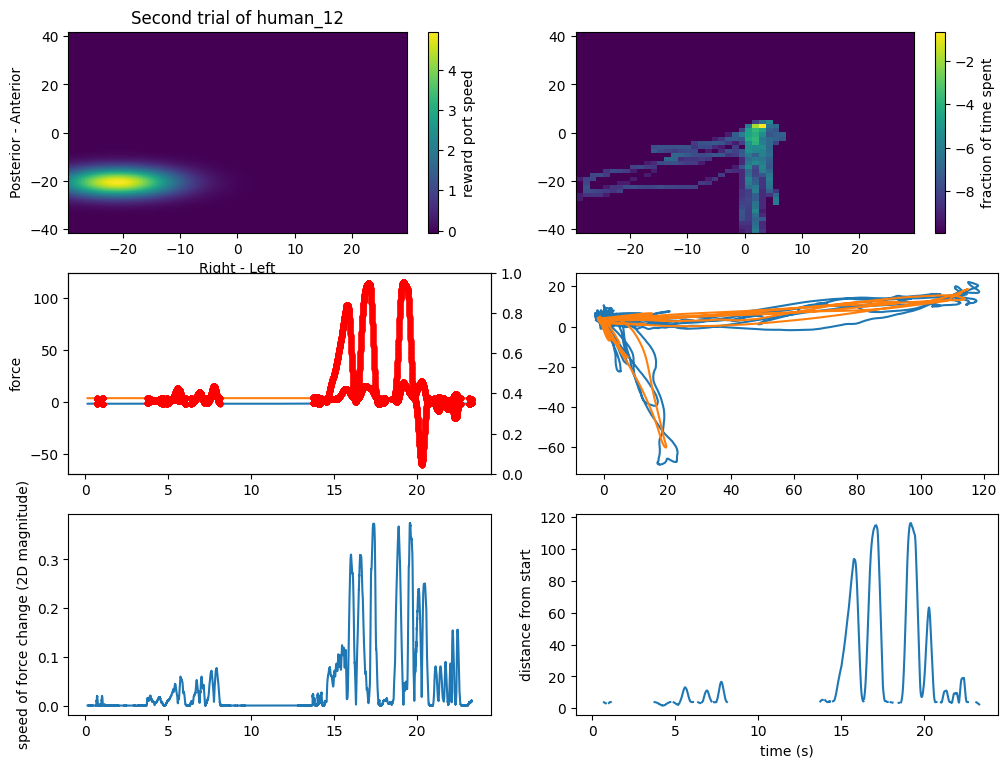

In [28]:
import matplotlib.pyplot as plt
import numpy as np
subtract_force_median = False
force_uniform_range = False
uniform_force_range= np.asarray([-1,1,-1,1])*100
subtract_median = False
smooth_window = 300
sd_window = 60
threshold_distance_for_hold = 40
trial_needed = 0


for subject_id in subject_ids_ordered[11:]:
    available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
    if 0 not in available_sessions:
        print(f'{subject_id} does not have session 0')
        continue
    # visualize targets, and how forces change over sessions and trials
    session = 0

    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    task_setting_id = task_setting_ids[0]
    target_force_lut = target_force_luts[0]

    fig = plt.figure(figsize=(12,12))
    ax_target_LUT = fig.add_subplot(4,2,1)
    force_axes_dict = {}
    for fa in force_axes:
        if fa['task_setting_id'] == task_setting_id:
            force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                'target_force_axes':fa['target_force_axes']}
    if force_uniform_range:
        im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
    im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                origin='upper',
                                                cmap='viridis',
                                                aspect='auto')
    plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
    plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
    plt.colorbar(im_lut,label='reward port speed')
    plt.title('Second trial of {}'.format(subject_id))

    
    if force_uniform_range:
        ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
        ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])



    ax_force_hist = fig.add_subplot(4,2,2)
    force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    if subtract_median:
        force_traces_0 = force_traces_0 - np.median(force_traces_0)
        force_traces_1 = force_traces_1 - np.median(force_traces_1)
        force_traces_2 = force_traces_2 - np.median(force_traces_2)
    force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('force_trace_time')
    reward_port_time, reward_port_position = (experiment.TrialRewardPortPosition*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('reward_port_position_time','reward_port_position_values')


    if force_uniform_range:
        histrange = [uniform_force_range[:2],uniform_force_range[:2]]
    else:
        histrange = [[force_axes_dict[0]['target_force_axes'][0],
                    force_axes_dict[0]['target_force_axes'][-1]],
                    [force_axes_dict[1]['target_force_axes'][0],
                    force_axes_dict[1]['target_force_axes'][-1]]]
    
    try:
        forcehist,binx,biny = np.histogram2d(force_traces_0,
                                            force_traces_1,
                                            range=histrange,
                                            bins=50)
        forcehist_all = forcehist.copy()
        forcehist = np.log(forcehist/sum(forcehist.flatten()))
        forcehist_ = forcehist.copy()
        forcehist_ [np.isinf(forcehist )] = 0
        forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
        im_hist = ax_force_hist.imshow(forcehist,
                                    extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                        alpha = 1,
                                        aspect= 'auto')
        plt.colorbar(im_hist,label = 'fraction of time spent')
    except:
        pass



   

    ax1 = fig.add_subplot(4,2,3)
    ax1_position = ax1.twinx()
    ax2 = fig.add_subplot(4,2,4)
    ax3 = fig.add_subplot(4,2,5,sharex=ax1)
    ax_sd = fig.add_subplot(4,2,6,sharex=ax1)



    force_trace_0_smooth = np.convolve(force_traces_0,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_1_smooth = np.convolve(force_traces_1,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
    force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    #holding_times = distance_from_start_smooth>threshold_distance_for_hold



    force_time = np.arange(len(force_traces_0))*np.median(np.diff(np.concatenate(force_trace_time)))
    force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

    distance_from_start = np.sqrt(force_traces_0**2 + force_traces_1**2)
    distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

    holding_times = distance_from_start_smooth>threshold_distance_for_hold

    force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2)
    force_magnitude_smooth_sd = pd.Series(force_magnitude_smooth).rolling(window=sd_window).std()
    contact_times = force_magnitude_smooth_sd>.05#np.percentile(force_magnitude_smooth_sd,5)

    force_angle_smooth = np.degrees(np.arctan2(force_trace_1_smooth, force_trace_0_smooth)) 

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    online_vector_angle = np.degrees(np.arctan2(np.diff(force_trace_1_smooth), np.diff(force_trace_0_smooth)))
    movement_threshold = 0.001
    movement_times = online_vector_magnitude>movement_threshold

    ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_0_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_1_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[1]['force_direction']])
    
    ax1.set_ylabel('force')

    ax2.plot(force_traces_0,force_traces_1)
    ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
    #ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


    d0 = np.diff(force_trace_0_smooth)
    d1 = np.diff(force_trace_1_smooth)
    speed_2d = np.sqrt(d0**2 + d1**2)

    ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
    ax3.set_ylabel('speed of force change (2D magnitude)')


    mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)


    distance_from_start_smooth[contact_times==False] = np.nan
    ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
    #ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
    ax_sd.set_xlabel('time (s)')
    ax_sd.set_ylabel('distance from start')

    break


    
    

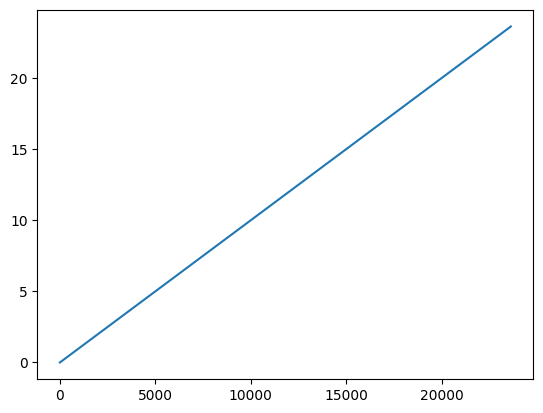

In [29]:
plt.plot(reward_port_time[0])

ValueError: zero-dimensional arrays cannot be concatenated

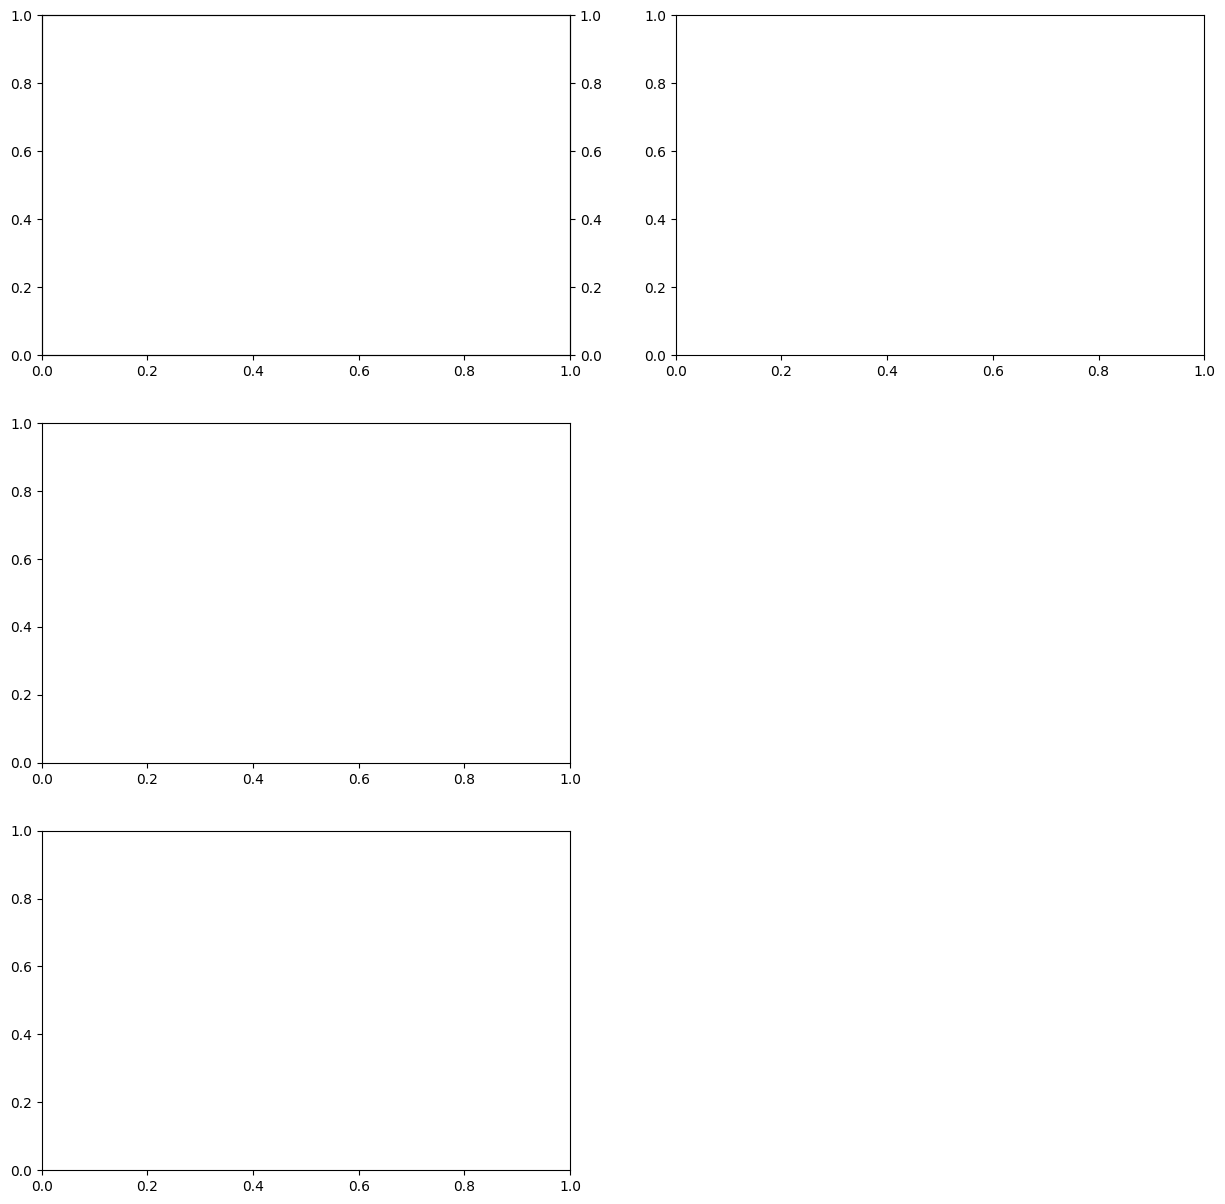

In [ ]:
smooth_window = 30
sd_window = 60
threshold_distance_for_hold = 40
needed_trials = [18]

fig= plt.figure(figsize = [15,15])
ax1 = fig.add_subplot(3,2,1)
ax1_position = ax1.twinx()
ax2 = fig.add_subplot(3,2,2)
ax3 = fig.add_subplot(3,2,3,sharex=ax1)
ax_sd = fig.add_subplot(3,2,5,sharex=ax1)
force_trace_0 = np.concatenate(force_traces_0[needed_trials])
force_trace_1 = np.concatenate(force_traces_1[needed_trials])

reward_port_time_now = np.concatenate(reward_port_time[needed_trials])
reward_port_position_now = np.concatenate(reward_port_position[needed_trials])
reward_port_time_now =  np.arange(len(reward_port_position_now))*np.median(np.diff(np.concatenate(reward_port_time[needed_trials])[::2])/2)

force_trace_0_smooth = np.convolve(force_trace_0,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_1_smooth = np.convolve(force_trace_1,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

distance_from_start = np.sqrt(np.concatenate(force_traces_0[needed_trials])**2+np.concatenate(force_traces_1[needed_trials])**2)
distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

holding_times = distance_from_start_smooth>threshold_distance_for_hold



force_time = np.arange(len(force_trace_0))*np.median(np.diff(np.concatenate(force_trace_time)))
force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
ax1.set_ylabel('force')
#ax1_position.plot(reward_port_time_now,reward_port_position_now,'k--',label='reward port position')

ax2.plot(force_trace_0,force_trace_1)
ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


#ax3.plot(force_time_smooth[:-1],np.diff(force_trace_0_smooth),label=direction_dict[force_axes_dict[0]['force_direction']])
#ax3.plot(force_time_smooth[:-1],np.diff(force_trace_1_smooth),label=direction_dict[force_axes_dict[1]['force_direction']])
#ax3.set_ylabel('speed of force change')

d0 = np.diff(force_trace_0_smooth)
d1 = np.diff(force_trace_1_smooth)
speed_2d = np.sqrt(d0**2 + d1**2)

ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
ax3.set_ylabel('speed of force change (2D magnitude)')


mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)
ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
ax_sd.set_xlabel('time (s)')
ax_sd.set_ylabel('distance from start')
#ax_sd.plot(force_time_smooth,mean_sd,label='mean sd')
#
#ax_sd.plot(force_time_smooth,force_trace_0_sd,label=direction_dict[force_axes_dict[0]['force_direction']])
#ax_sd.plot(force_time_smooth,force_trace_1_sd,label=direction_dict[force_axes_dict[1]['force_direction']])
#plt.xlim([5,10])

Text(0, 0.5, 'speed of force change (2D magnitude)')

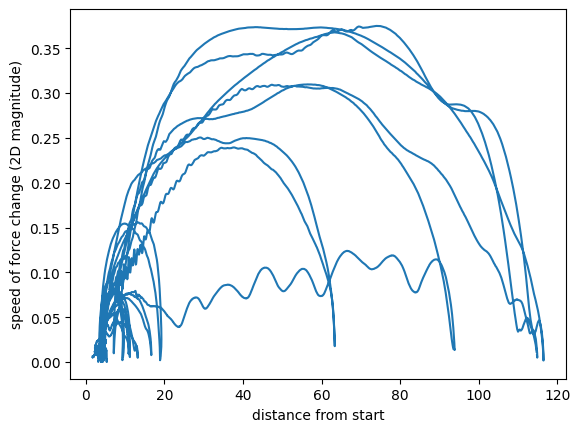

In [ ]:
plt.plot(distance_from_start_smooth[:-1],speed_2d)
plt.xlabel('distance from start')
plt.ylabel('speed of force change (2D magnitude)')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
subtract_force_median = False
force_uniform_range = True
uniform_force_range= np.asarray([-1,1,-1,1])*100
subtract_median = False
smooth_window = 300
sd_window = 60
threshold_distance_for_hold = 40
trial_needed = 6


for subject_id in subject_ids_ordered[5]:
    available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
    if 0 not in available_sessions:
        print(f'{subject_id} does not have session 0')
        continue
    # visualize targets, and how forces change over sessions and trials
    session = 0

    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    task_setting_id = task_setting_ids[0]
    target_force_lut = target_force_luts[0]

    fig = plt.figure(figsize=(12,12))
    ax_target_LUT = fig.add_subplot(4,2,1)
    force_axes_dict = {}
    for fa in force_axes:
        if fa['task_setting_id'] == task_setting_id:
            force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                'target_force_axes':fa['target_force_axes']}
    if force_uniform_range:
        im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
    im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                origin='upper',
                                                cmap='viridis',
                                                aspect='auto')
    plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
    plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
    plt.colorbar(im_lut,label='reward port speed')
    plt.title('Second trial of {}'.format(subject_id))

    
    if force_uniform_range:
        ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
        ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])



    ax_force_hist = fig.add_subplot(4,2,2)
    force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch1('force_trace_value')
    if subtract_median:
        force_traces_0 = force_traces_0 - np.median(force_traces_0)
        force_traces_1 = force_traces_1 - np.median(force_traces_1)
        force_traces_2 = force_traces_2 - np.median(force_traces_2)
    force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('force_trace_time')
    reward_port_time, reward_port_position = (experiment.TrialRewardPortPosition*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id, 'trial':trial_needed}).fetch('reward_port_position_time','reward_port_position_values')


    if force_uniform_range:
        histrange = [uniform_force_range[:2],uniform_force_range[:2]]
    else:
        histrange = [[force_axes_dict[0]['target_force_axes'][0],
                    force_axes_dict[0]['target_force_axes'][-1]],
                    [force_axes_dict[1]['target_force_axes'][0],
                    force_axes_dict[1]['target_force_axes'][-1]]]
    
    try:
        forcehist,binx,biny = np.histogram2d(force_traces_0,
                                            force_traces_1,
                                            range=histrange,
                                            bins=50)
        forcehist_all = forcehist.copy()
        forcehist = np.log(forcehist/sum(forcehist.flatten()))
        forcehist_ = forcehist.copy()
        forcehist_ [np.isinf(forcehist )] = 0
        forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
        im_hist = ax_force_hist.imshow(forcehist,
                                    extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                        alpha = 1,
                                        aspect= 'auto')
        plt.colorbar(im_hist,label = 'fraction of time spent')
    except:
        pass



   

    ax1 = fig.add_subplot(4,2,3)
    ax1_position = ax1.twinx()
    ax2 = fig.add_subplot(4,2,4)
    ax3 = fig.add_subplot(4,2,5,sharex=ax1)
    ax_sd = fig.add_subplot(4,2,6,sharex=ax1)



    force_trace_0_smooth = np.convolve(force_traces_0,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_1_smooth = np.convolve(force_traces_1,np.ones(smooth_window)/smooth_window,mode='valid')
    force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
    force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    #holding_times = distance_from_start_smooth>threshold_distance_for_hold



    force_time = np.arange(len(force_traces_0))*np.median(np.diff(np.concatenate(force_trace_time)))
    force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

    distance_from_start = np.sqrt(force_traces_0**2 + force_traces_1**2)
    distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

    holding_times = distance_from_start_smooth>threshold_distance_for_hold

    force_magnitude_smooth = np.sqrt(force_trace_0_smooth**2 + force_trace_1_smooth**2)
    force_magnitude_smooth_sd = pd.Series(force_magnitude_smooth).rolling(window=sd_window).std()
    contact_times = force_magnitude_smooth_sd>.05#np.percentile(force_magnitude_smooth_sd,5)

    force_angle_smooth = np.degrees(np.arctan2(force_trace_1_smooth, force_trace_0_smooth)) 

    online_vector_magnitude = np.sqrt(np.diff(force_trace_0_smooth)**2 + np.diff(force_trace_1_smooth)**2)
    online_vector_angle = np.degrees(np.arctan2(np.diff(force_trace_1_smooth), np.diff(force_trace_0_smooth)))
    movement_threshold = 0.001
    movement_times = online_vector_magnitude>movement_threshold

    ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_0_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[0]['force_direction']])
    ax1.plot(force_time_smooth[contact_times],force_trace_1_smooth[contact_times],'r.',label=direction_dict[force_axes_dict[1]['force_direction']])
    
    ax1.set_ylabel('force')

    ax2.plot(force_traces_0,force_traces_1)
    ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
    #ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


    d0 = np.diff(force_trace_0_smooth)
    d1 = np.diff(force_trace_1_smooth)
    speed_2d = np.sqrt(d0**2 + d1**2)

    ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
    ax3.set_ylabel('speed of force change (2D magnitude)')


    mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)


    distance_from_start_smooth[contact_times==False] = np.nan
    ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
    #ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
    ax_sd.set_xlabel('time (s)')
    ax_sd.set_ylabel('distance from start')

    break


    
    

h does not have session 0
u does not have session 0
m does not have session 0
a does not have session 0
n does not have session 0
_ does not have session 0
6 does not have session 0


Fetching data…
Done.
human_11 (block 0): 8.05–10.00 s  (1966 samples, total 93.86 s)


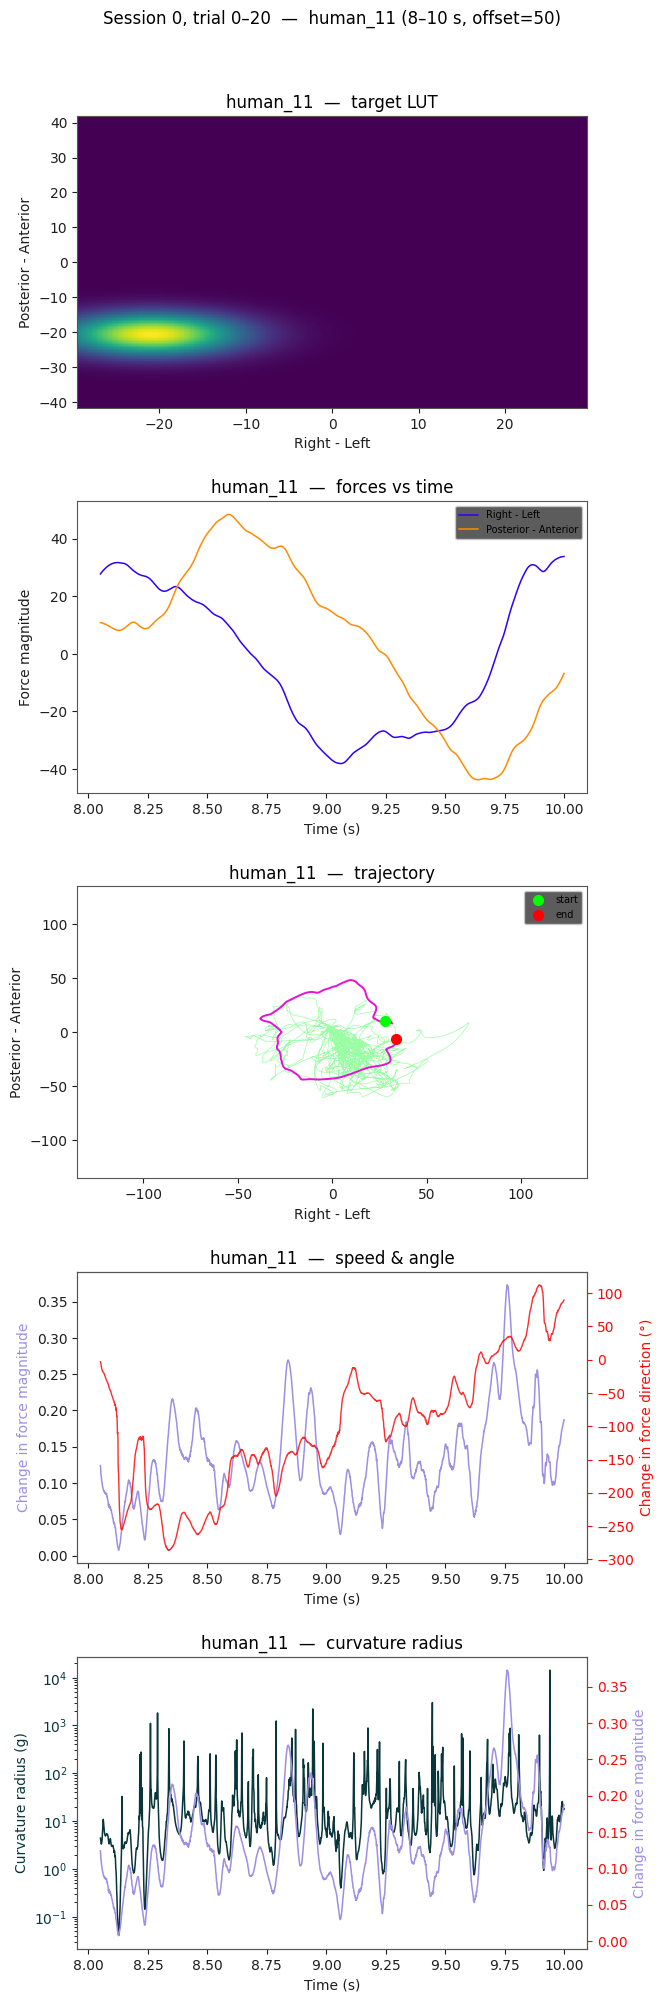

In [ ]:

# ── parameters ────────────────────────────────────────────────────────────────
subjects      = ['human_11']
t_ranges      = [(8, 10)]
start_offset  = 50
session       = 0
trial         = [0, 21]     # single int  OR  [start, end] to concatenate a range
block         = None        # None → first available block; or set e.g. 0, 1, 2 …
smooth_window = 30
language      = 'en'        # 'en' or 'hu'

# ── labels ────────────────────────────────────────────────────────────────────
_L = {
    'en': dict(
        dir         = {'LR': 'Left - Right', 'RL': 'Right - Left',
                       'AP': 'Anterior - Posterior', 'PA': 'Posterior - Anterior'},
        lut_title   = '{subj}  —  target LUT',
        force_title = '{subj}  —  forces vs time',
        force_y     = 'Force magnitude',
        traj_title  = '{subj}  —  trajectory',
        start       = 'start', end = 'end',
        vec_title   = '{subj}  —  speed & angle',
        vec_mag     = 'Change in force magnitude',
        vec_ang     = 'Change in force direction (°)',
        curv_title  = '{subj}  —  curvature radius',
        curv_y      = 'Curvature radius (g)',
        time_x      = 'Time (s)',
        sess_word   = 'Session', trial_word = 'trial',
        offset_word = 'offset', vs_word = 'vs',
    ),
    'hu': dict(
        dir         = {'LR': 'Bal - Jobb', 'RL': 'Jobb - Bal',
                       'AP': 'Elöl - Hátul', 'PA': 'Hátul - Elöl'},
        lut_title   = '{subj}  —  célerő térkép',
        force_title = '{subj}  —  erők az idő függvényében',
        force_y     = 'Erő nagysága',
        traj_title  = '{subj}  —  trajektória',
        start       = 'kezdet', end = 'vég',
        vec_title   = '{subj}  —  sebesség & szög',
        vec_mag     = 'Erő nagyságának változása',
        vec_ang     = 'Erő irányának változása (°)',
        curv_title  = '{subj}  —  görbület sugara',
        curv_y      = 'Görbület sugara (g)',
        time_x      = 'Idő (s)',
        sess_word   = 'Munkamenet', trial_word = 'próba',
        offset_word = 'eltolás', vs_word = 'vs',
    ),
}
L = _L[language]

DARK  = "#ffffff"
BG    = "#ffffff"
C_F0  = "#2f00ff"
C_F1  = "#ff8c00"
C_MAG = "#9e8fe4"
C_ANG = "#fc0808"
C_CRV = "#09363b"

# ── helper: fetch + preprocess one subject ────────────────────────────────────

import numpy as np

##


def menger_curvature_radius(x, y, half_window=1):
    """
    Radius of curvature using three-point (Menger) formula.
    Uses points [i - half_window, i, i + half_window] to reduce noise sensitivity.
    """
    n = len(x)
    radius = np.full(n, np.inf)

    for i in range(half_window, n - half_window):
        x1, y1 = x[i - half_window], y[i - half_window]
        x2, y2 = x[i],               y[i]
        x3, y3 = x[i + half_window], y[i + half_window]

        # Side lengths
        a = np.hypot(x2 - x1, y2 - y1)
        b = np.hypot(x3 - x2, y3 - y2)
        c = np.hypot(x3 - x1, y3 - y1)

        # Triangle area (cross product / 2)
        area = abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)) / 2

        if area > 1e-12:
            radius[i] = (a * b * c) / (4 * area)

    return radius

def _fetch(subject_id, session, trial, sw, block=None):
    # resolve block → task_setting_id
    avail_blocks = (experiment.Block() &
                    {'subject_id': subject_id, 'session': session}).fetch('block')
    if len(avail_blocks) == 0:
        avail_sessions = (experiment.Session() & {'subject_id': subject_id}).fetch('session')
        raise ValueError(f"No blocks for {subject_id} session {session}. "
                         f"Available sessions: {avail_sessions}")
    blk = block if block is not None else avail_blocks[0]

    tsid, lut = (experiment.TaskSettings() * experiment.Block() &
                 {'subject_id': subject_id, 'session': session,
                  'block': blk}).fetch1('task_setting_id', 'target_force_lut')

    fa_rows = (experiment.TaskSettings.ForceAxis() &
               {'subject_id': subject_id, 'session': session}).fetch(as_dict=True)
    fad = {r['force_axis_idx']: {'force_direction':   r['force_direction'],
                                  'target_force_axes': r['target_force_axes']}
           for r in fa_rows if r['task_setting_id'] == tsid}

    # join via Block (not TaskSettings) to get correct per-trial filtering
    base = (experiment.TrialForceTrace.TrialForceAxis() *
            experiment.BehaviorTrial() * experiment.Block())

    trial_list = (list(range(int(trial[0]), int(trial[1])))
                  if isinstance(trial, (list, tuple)) and not isinstance(trial, int)
                  else [int(trial)])

    f0_parts, f1_parts, t_parts = [], [], []
    for tr in trial_list:
        key = {'subject_id': subject_id, 'session': session, 'block': blk, 'trial': tr}
        try:
            f0r = (base & {**key, 'force_axis_idx': 0}).fetch1('force_trace_value')
            f1r = (base & {**key, 'force_axis_idx': 1}).fetch1('force_trace_value')
            t_chunks = (experiment.TrialForceTrace() * experiment.BehaviorTrial() *
                        experiment.Block() & key).fetch('force_trace_time')
            dt = np.median(np.diff(np.concatenate(t_chunks)))
            f0_parts.append(f0r);  f1_parts.append(f1r)
            t_parts.append(np.arange(len(f0r)) * dt)
        except Exception as e:
            print(f"  skipping trial {tr}: {e}")

    t_cont, offset = [], 0.0
    for tp in t_parts:
        t_cont.append(tp + offset)
        offset += tp[-1] + (tp[1] - tp[0]) if len(tp) > 1 else tp[-1]
    raw_t   = np.concatenate(t_cont)
    f0r_all = np.concatenate(f0_parts)
    f1r_all = np.concatenate(f1_parts)

    f0  = np.convolve(f0r_all, np.ones(sw)/sw, mode='valid')
    f1  = np.convolve(f1r_all, np.ones(sw)/sw, mode='valid')
    t   = np.convolve(raw_t,   np.ones(sw)/sw, mode='valid')
    mag = np.sqrt(np.diff(f0)**2 + np.diff(f1)**2)
    ang = np.degrees(np.unwrap(np.arctan2(np.diff(f1), np.diff(f0))))
    curvature_radius = menger_curvature_radius(f0, f1, half_window=5)#compute_trajectory_kinematics

    return dict(f0=f0, f1=f1, t=t, mag=mag, ang=ang, lut=lut, fad=fad, block=blk,
                curvature_radius=curvature_radius)

print("Fetching data…")
data = [_fetch(s, session, trial, smooth_window, block) for s in subjects]
print("Done.")

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, len(subjects), figsize=(7 * len(subjects), 20), facecolor=DARK)
if len(subjects) == 1:
    axes = axes[:, np.newaxis]

_trial_str = f"{trial[0]}–{trial[1]-1}" if isinstance(trial, (list,tuple)) else str(trial)
_parts = [f"{s} ({tr[0]}–{tr[1]} s, {L['offset_word']}={start_offset})"
          for s, tr in zip(subjects, t_ranges)]
fig.suptitle(
    f"{L['sess_word']} {session}, {L['trial_word']} {_trial_str}  —  "
    + f"  {L['vs_word']}  ".join(_parts),
    color='black', fontsize=12, y=1.005)

for ax in axes.flat:
    ax.set_facecolor(BG)
    ax.tick_params(colors="#1f1e1e")
    for sp in ax.spines.values():
        sp.set_edgecolor('#555')
    ax.xaxis.label.set_color("#1f1e1e")
    ax.yaxis.label.set_color("#1f1e1e")
    ax.title.set_color('black')

for col, (d, subj, (t0, t1)) in enumerate(zip(data, subjects, t_ranges)):
    f0, f1, ts = d['f0'], d['f1'], d['t']
    mag, ang   = d['mag'], d['ang']
    curv_r     = d['curvature_radius']
    t_v = ts[:-1];  lut = d['lut'];  fad = d['fad'];  N = len(ts)

    i0_raw = min(int(np.searchsorted(ts, t0)), N - 1)
    i1     = min(int(np.searchsorted(ts, t1)), N - 1)
    i0     = min(i0_raw + start_offset, i1)
    sl     = slice(i0, i1)
    sl_v   = slice(i0, min(i1, len(mag)))
    sl_c   = slice(i0, min(i1, len(curv_r)))

    print(f"{subj} (block {d['block']}): {ts[i0]:.2f}–{ts[i1]:.2f} s  "
          f"({i1-i0} samples, total {ts[-1]:.2f} s)")

    dir0 = L['dir'][fad[0]['force_direction']]
    dir1 = L['dir'][fad[1]['force_direction']]

    # row 0: target LUT
    ax = axes[0, col]
    ax.imshow(lut,
              extent=[fad[0]['target_force_axes'][0], fad[0]['target_force_axes'][-1],
                      fad[1]['target_force_axes'][0], fad[1]['target_force_axes'][-1]],
              origin='upper', cmap='viridis', aspect='auto')
    ax.set_xlabel(dir0);  ax.set_ylabel(dir1)
    ax.set_title(L['lut_title'].format(subj=subj), color='black')

    # row 1: force vs time
    ax = axes[1, col]
    ax.plot(ts[sl], f0[sl], color=C_F0, lw=1.1, label=dir0)
    ax.plot(ts[sl], f1[sl], color=C_F1, lw=1.1, label=dir1)
    ax.set_xlabel(L['time_x']);  ax.set_ylabel(L['force_y'])
    ax.set_title(L['force_title'].format(subj=subj), color='black')
    ax.legend(fontsize=7, facecolor='#333', labelcolor='black', loc='upper right')

    # row 2: trajectory
    ax = axes[2, col]
    ax.plot(f0, f1, color="#07fd1f", lw=0.5, alpha=0.4)
    ax.plot(f0[sl], f1[sl], color="#e910da", lw=1.4, zorder=3)
    ax.plot(f0[i0], f1[i0], 'o', color='lime', ms=7, zorder=4, label=L['start'])
    ax.plot(f0[i1], f1[i1], 'o', color='red',  ms=7, zorder=4, label=L['end'])
    ax.set_xlabel(dir0);  ax.set_ylabel(dir1)
    ax.set_xlim(-135, 135);  ax.set_ylim(-135, 135)
    ax.set_title(L['traj_title'].format(subj=subj), color='black')
    ax.legend(fontsize=7, facecolor='#333', labelcolor='black')

    # row 3: speed & angle (twin axes)
    ax  = axes[3, col]
    axr = ax.twinx()
    axr.set_facecolor(BG);  axr.tick_params(colors=C_ANG)
    axr.yaxis.label.set_color(C_ANG)
    for sp in axr.spines.values():
        sp.set_edgecolor('#555')

    ang_win     = ang[sl_v]
    ang_centred = ang_win - np.round(np.nanmean(ang_win) / 360) * 360

    ax.plot(t_v[sl_v], mag[sl_v], color=C_MAG, lw=1.1)
    axr.plot(t_v[sl_v], ang_centred, color=C_ANG, lw=1.0, alpha=0.85)
    ax.set_xlabel(L['time_x'])
    ax.set_ylabel(L['vec_mag'], color=C_MAG)
    axr.set_ylabel(L['vec_ang'], color=C_ANG)
    ax.set_title(L['vec_title'].format(subj=subj), color='black')

    # row 4: curvature κ = 1/R (clip radius so straight segments → 0, not inf)
    ax  = axes[4, col]
    axr4 = ax.twinx()
    axr4.set_facecolor(BG);  axr4.tick_params(colors=C_ANG)
    axr4.yaxis.label.set_color(C_ANG)
    for sp in axr4.spines.values():
        sp.set_edgecolor('#555')

    cr_win = curv_r[sl_c]
    curv   = np.where(np.isfinite(cr_win), 1.0 / np.clip(cr_win, 1e-3, None), 0.0)

    ang_c_win     = ang[slice(i0, min(i1, len(ang)))]
    ang_c_centred = ang_c_win - np.round(np.nanmean(ang_c_win) / 360) * 360

    ax.plot(ts[sl_c],cr_win, color=C_CRV, lw=1.1, label='radius of curvature')
    axr4.plot(t_v[sl_v], mag[sl_v], color=C_MAG, lw=1.1)
    # axr4.plot(t_v[slice(i0, min(i1, len(ang)))], ang_c_centred,
    #           color=C_MAG, lw=1.0, alpha=0.70, label='angle')
    ax.set_xlabel(L['time_x'])
    ax.set_ylabel(L['curv_y'], color=C_CRV)
    axr4.set_ylabel(L['vec_mag'], color=C_MAG)
    ax.set_title(L['curv_title'].format(subj=subj), color='black')
    ax.tick_params(axis='y', colors=C_CRV)
    ax.set_yscale('log')
   # ax.set_ylim(-.50, 100)

fig.tight_layout(pad=2.0)
#plt.xlim([5,12.5])
plt.show()


(0.0, 1000.0)

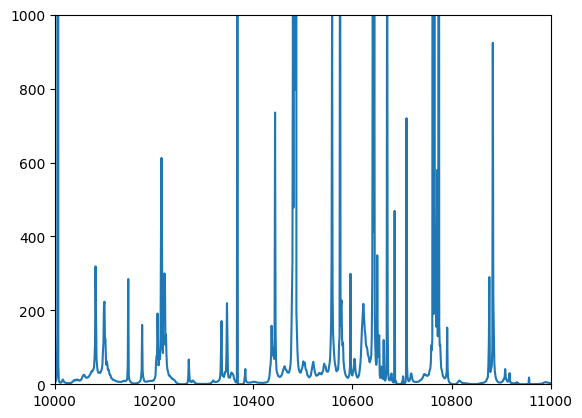

In [ ]:
plt.plot(data[0]['curvature_radius'])
plt.xlim([10000,11000])
plt.ylim([0,1000])


Available blocks in session 0: {0: '1D_speed', 1: '2D_speed', 2: '0D_speed', 3: '1D_speed', 4: '1D_position', 5: '2D_position'}

Trial availability per block:
  block 0: 156 trials  (abs #0–#155)
  block 1: 156 trials  (abs #0–#155)
  block 2: 156 trials  (abs #0–#155)
  block 3: 156 trials  (abs #0–#155)
  block 4: 156 trials  (abs #0–#155)
  block 5: 156 trials  (abs #0–#155)

blocks_trials (relative indices) = {0: [0, 10], 1: [0, 10], 2: [0, 10]}

Block 0: using trials #0–#9  (idx 0–9)
Block 1: using trials #0–#9  (idx 0–9)
Block 2: using trials #0–#9  (idx 0–9)

 Block              Trials   Loaded    Samples     Bins   Area mm²   Coverage
──────────────────────────────────────────────────────────────────────────────
     0    #0–#9  (idx 0–9)       10    230,692    4,623     4623.0      93.3%
     1    #0–#9  (idx 0–9)       10    230,692    4,623     4623.0      93.3%
     2    #0–#9  (idx 0–9)       10    230,692    4,623     4623.0      93.3%
────────────────────────────────────

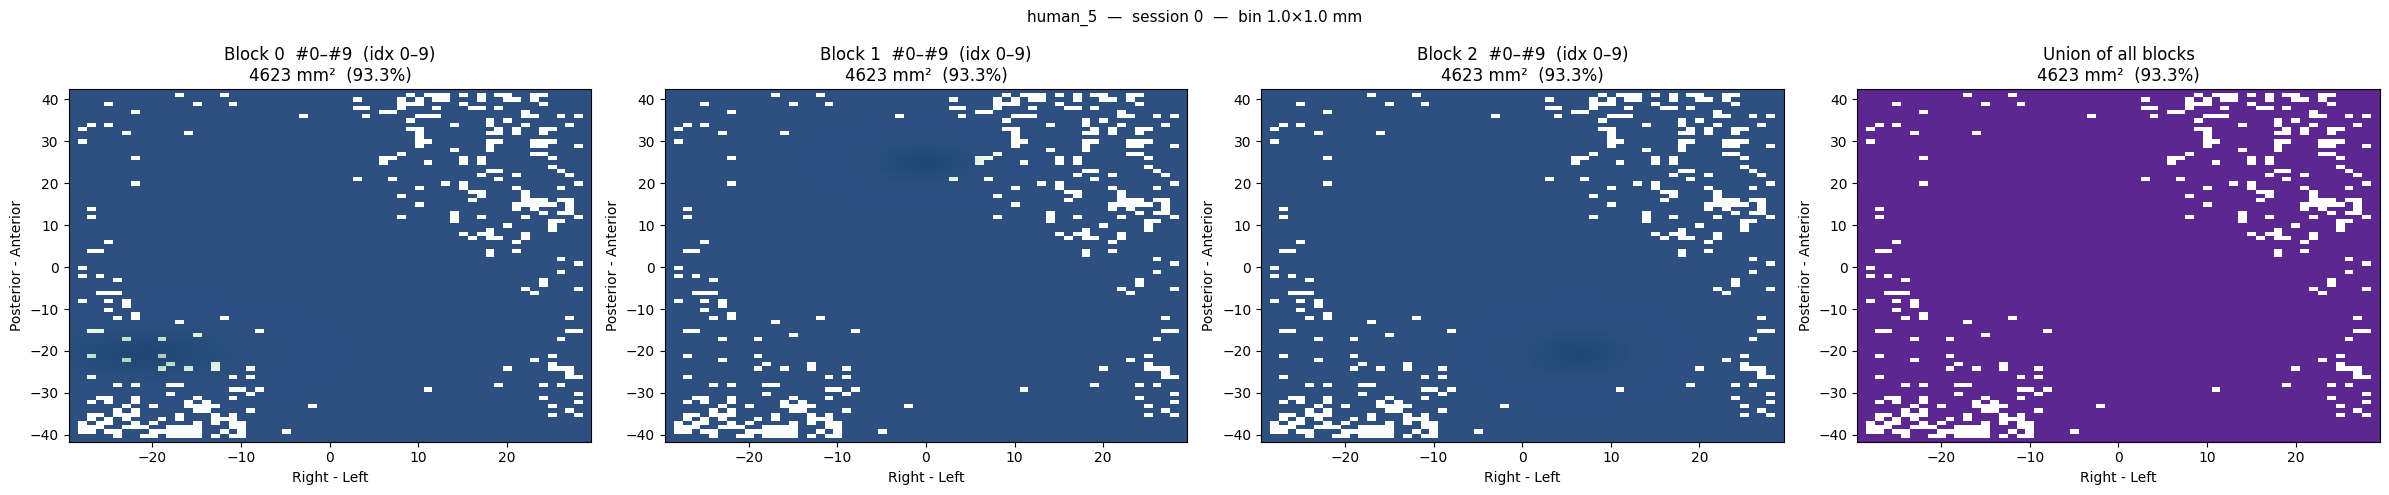

In [ ]:

# ── AREA EXPLORED ─────────────────────────────────────────────────────────────
# Workspace is divided into bin_size × bin_size mm bins.
# Area explored = number of unique bins visited × bin_size² mm².
#
# Trial ranges are RELATIVE indices within each block:
#   [0, 10]  → first 10 trials of that block
#   [10, 20] → trials 10–19 of that block (by position, not absolute number)
#   None     → all trials in the block
# ── parameters ────────────────────────────────────────────────────────────────
subject_id_area = 'human_5'
session_area    = 0

blocks_trials = {
    0: [0, 10],
    1: [0, 10],
    2: [0, 10],
}
# Set blocks_trials = None to auto-use all blocks with all their trials.

bin_size_mm     = 1.0   # bin size in force units (mm)
workspace_range = None  # None → sensor range; or [-100, 100, -100, 100]

# ── discover available blocks ─────────────────────────────────────────────────
_avail_blocks, _avail_feedback = (
    experiment.Block() & {'subject_id': subject_id_area, 'session': session_area}
).fetch('block', 'feedback_type')

if len(_avail_blocks) == 0:
    print(f"No blocks found for {subject_id_area} session {session_area}.")
    for _s in (experiment.Session() & {'subject_id': subject_id_area}).fetch('session'):
        _bs = (experiment.Block() & {'subject_id': subject_id_area, 'session': _s}).fetch('block')
        print(f"  session {_s}: blocks {_bs}")
    raise StopIteration("Fix subject_id_area / session_area and re-run.")

print(f"Available blocks in session {session_area}: "
      f"{dict(zip(_avail_blocks.tolist(), _avail_feedback.tolist()))}")

# ── build trial map via TrialForceTrace (more reliable than BehaviorTrial join) ──
print("\nTrial availability per block:")
_block_trial_map = {}
for _b in _avail_blocks:
    _trs = np.sort(np.unique(
        (experiment.TrialForceTrace.TrialForceAxis() * experiment.Block() &
         {'subject_id': subject_id_area, 'session': session_area,
          'block': int(_b), 'force_axis_idx': 0}).fetch('trial')
    ))
    _block_trial_map[int(_b)] = _trs
    _lo = _trs[0] if len(_trs) else '—'
    _hi = _trs[-1] if len(_trs) else '—'
    print(f"  block {_b}: {len(_trs)} trials  (abs #{_lo}–#{_hi})")

# For any block in blocks_trials that's missing from the map, try a direct lookup
if blocks_trials is not None:
    for _b in list(blocks_trials.keys()):
        if int(_b) not in _block_trial_map:
            print(f"  block {_b}: not returned by experiment.Block() — trying direct TrialForceTrace lookup...")
            _trs_direct = np.sort(np.unique(
                (experiment.TrialForceTrace.TrialForceAxis() &
                 {'subject_id': subject_id_area, 'session': session_area,
                  'force_axis_idx': 0}).fetch('trial')
            ))
            _block_trial_map[int(_b)] = _trs_direct
            _lo = _trs_direct[0] if len(_trs_direct) else '—'
            _hi = _trs_direct[-1] if len(_trs_direct) else '—'
            print(f"    → found {len(_trs_direct)} trials (#{_lo}–#{_hi})  "
                  f"NOTE: block key unavailable; using all session trials as fallback")

# auto-fill if not specified
if blocks_trials is None:
    blocks_trials = {int(_b): None for _b in _avail_blocks}

print(f"\nblocks_trials (relative indices) = {blocks_trials}\n")

# ── shared workspace definition ───────────────────────────────────────────────
_first_block = list(blocks_trials.keys())[0]
_first_tsid  = (experiment.TaskSettings() * experiment.Block() &
                {'subject_id': subject_id_area, 'session': session_area,
                 'block': _first_block}).fetch1('task_setting_id')
_fa_rows_all = (experiment.TaskSettings.ForceAxis() &
                {'subject_id': subject_id_area, 'session': session_area}).fetch(as_dict=True)
_fad_global  = {r['force_axis_idx']: r
                for r in _fa_rows_all if r['task_setting_id'] == _first_tsid}

if workspace_range is not None:
    _x_min, _x_max, _y_min, _y_max = workspace_range
else:
    _x_min = _fad_global[0]['target_force_axes'][0]
    _x_max = _fad_global[0]['target_force_axes'][-1]
    _y_min = _fad_global[1]['target_force_axes'][0]
    _y_max = _fad_global[1]['target_force_axes'][-1]

_x_edges    = np.arange(_x_min, _x_max + bin_size_mm, bin_size_mm)
_y_edges    = np.arange(_y_min, _y_max + bin_size_mm, bin_size_mm)
_nx, _ny    = len(_x_edges) - 1, len(_y_edges) - 1
_total_bins = _nx * _ny
_dir0       = direction_dict[_fad_global[0]['force_direction']]
_dir1       = direction_dict[_fad_global[1]['force_direction']]
_ext        = [_x_edges[0], _x_edges[-1], _y_edges[0], _y_edges[-1]]

# ── process each block ────────────────────────────────────────────────────────
_results    = {}
_union_bins = set()

for _block, _t_range in blocks_trials.items():
    # resolve relative indices → absolute trial numbers
    _all_trials = _block_trial_map.get(int(_block), np.array([]))
    if len(_all_trials) == 0:
        print(f"Block {_block}: no trials found, skipping.")
        continue

    if _t_range is None:
        _trial_list = _all_trials.tolist()
        _trial_str  = f"{_all_trials[0]}–{_all_trials[-1]}"
    else:
        _i0, _i1    = int(_t_range[0]), int(_t_range[1])
        _selected   = _all_trials[_i0:_i1]
        if len(_selected) == 0:
            print(f"Block {_block}: range [{_i0},{_i1}) exceeds available "
                  f"{len(_all_trials)} trials — skipping.")
            continue
        _trial_list = _selected.tolist()
        _trial_str  = f"#{_selected[0]}–#{_selected[-1]}  (idx {_i0}–{_i1-1})"

    print(f"Block {_block}: using trials {_trial_str}")

    try:
        _tsid, _lut = (experiment.TaskSettings() * experiment.Block() &
                       {'subject_id': subject_id_area, 'session': session_area,
                        'block': _block}).fetch1('task_setting_id', 'target_force_lut')
    except Exception as _e:
        print(f"  could not fetch task settings — {_e}")
        continue

    _fad  = {r['force_axis_idx']: r
             for r in _fa_rows_all if r['task_setting_id'] == _tsid}

    # fetch force traces: try Block join first, fall back to trial-only join
    _f0_parts, _f1_parts = [], []
    for _tr in _trial_list:
        _key = {'subject_id': subject_id_area, 'session': session_area, 'trial': _tr}
        try:
            _q = (experiment.TrialForceTrace.TrialForceAxis() * experiment.Block() &
                  {**_key, 'block': _block})
            _f0_parts.append((_q & {'force_axis_idx': 0}).fetch1('force_trace_value'))
            _f1_parts.append((_q & {'force_axis_idx': 1}).fetch1('force_trace_value'))
        except Exception:
            try:
                _q2 = (experiment.TrialForceTrace.TrialForceAxis() * experiment.BehaviorTrial() & _key)
                _f0_parts.append((_q2 & {'force_axis_idx': 0}).fetch1('force_trace_value'))
                _f1_parts.append((_q2 & {'force_axis_idx': 1}).fetch1('force_trace_value'))
            except Exception:
                pass

    if len(_f0_parts) == 0:
        print(f"  no force traces found — skipping.")
        continue

    _f0 = np.concatenate(_f0_parts)
    _f1 = np.concatenate(_f1_parts)

    _xi = np.clip(np.digitize(_f0, _x_edges) - 1, 0, _nx - 1)
    _yi = np.clip(np.digitize(_f1, _y_edges) - 1, 0, _ny - 1)

    _visited = set(zip(_xi.tolist(), _yi.tolist()))
    _union_bins.update(_visited)

    _visit_map = np.zeros((_ny, _nx))
    for _xb, _yb in zip(_xi, _yi):
        _visit_map[_yb, _xb] += 1

    _results[_block] = dict(
        tsid=_tsid, lut=_lut, fad=_fad, visit_map=_visit_map,
        n_visited=len(_visited),
        area_mm2=len(_visited) * bin_size_mm**2,
        coverage_pct=100.0 * len(_visited) / _total_bins,
        n_trials=len(_f0_parts), n_samples=len(_f0),
        trial_str=_trial_str,
    )

# ── print summary ─────────────────────────────────────────────────────────────
print(f"\n{'Block':>6}  {'Trials':>18}  {'Loaded':>7}  {'Samples':>9}  "
      f"{'Bins':>7}  {'Area mm²':>9}  {'Coverage':>9}")
print("─" * 78)
for _b, _r in _results.items():
    print(f"{_b:>6}  {_r['trial_str']:>18}  {_r['n_trials']:>7}  {_r['n_samples']:>9,}  "
          f"{_r['n_visited']:>7,}  {_r['area_mm2']:>9.1f}  {_r['coverage_pct']:>8.1f}%")
_union_n    = len(_union_bins)
_union_area = _union_n * bin_size_mm**2
_union_cov  = 100.0 * _union_n / _total_bins
print("─" * 78)
print(f"{'UNION':>6}  {'':>18}  {'':>7}  {'':>9}  "
      f"{_union_n:>7,}  {_union_area:>9.1f}  {_union_cov:>8.1f}%")

# ── figure ─────────────────────────────────────────────────────────────────────
if len(_results) == 0:
    print("\nNo data to plot.")
else:
    _n_cols = len(_results) + 1
    fig, axes = plt.subplots(1, _n_cols, figsize=(6 * _n_cols, 5))
    if _n_cols == 1:
        axes = [axes]

    for _ax, (_b, _r) in zip(axes[:-1], _results.items()):
        _lut_norm = (_r['lut'] - _r['lut'].min()) / (_r['lut'].max() - _r['lut'].min() + 1e-9)
        _lut_ext  = [_r['fad'][0]['target_force_axes'][0], _r['fad'][0]['target_force_axes'][-1],
                     _r['fad'][1]['target_force_axes'][0], _r['fad'][1]['target_force_axes'][-1]]
        _ax.imshow(_lut_norm, extent=_lut_ext, origin='upper',
                   cmap='Greens', alpha=0.30, aspect='auto', zorder=0)
        _ax.imshow(np.ma.masked_where(_r['visit_map'] == 0, (_r['visit_map'] > 0).astype(float)),
                   extent=_ext, origin='lower', cmap='Blues',
                   alpha=0.85, aspect='auto', vmin=0, vmax=1, zorder=1)
        _ax.set_xlabel(_dir0);  _ax.set_ylabel(_dir1)
        _ax.set_title(f"Block {_b}  {_r['trial_str']}\n"
                      f"{_r['area_mm2']:.0f} mm²  ({_r['coverage_pct']:.1f}%)")

    _union_map = np.zeros((_ny, _nx))
    for _xb, _yb in _union_bins:
        _union_map[_yb, _xb] = 1
    axes[-1].imshow(np.ma.masked_where(_union_map == 0, _union_map),
                    extent=_ext, origin='lower', cmap='Purples',
                    alpha=0.85, aspect='auto', vmin=0, vmax=1)
    axes[-1].set_xlabel(_dir0);  axes[-1].set_ylabel(_dir1)
    axes[-1].set_title(f"Union of all blocks\n{_union_area:.0f} mm²  ({_union_cov:.1f}%)")

    fig.suptitle(f"{subject_id_area}  —  session {session_area}  —  bin {bin_size_mm}×{bin_size_mm} mm",
                 fontsize=11)
    plt.tight_layout()
    plt.show()
